# 7 . Monte Carlo con trayectorias visibles: medida Q vs medida P

El binding Python del motor (`engine.Engine`) exponía antes solo MEDIDAS agregadas sobre la
simulacion Monte Carlo (`PayoffPriceQ`, `PayoffForecastP`, `PayoffHitProbabilityQ/P`, ...) --
nunca las trayectorias individuales que simula por dentro. Este notebook nacio de esa
limitacion: la seccion 1 reimplementaba en NumPy puro la SDE del GBM solo para poder dibujar
un fan chart.

**`PLAN_IMPROVE_NOTEBOOK.md`, Fase 0 (implementada):** el motor expone ahora
`Engine.simulate_paths(model, market, pricing)`, que devuelve la matriz de trayectorias REAL
que `Gbm`/`GbmP` ya calculan por dentro (misma discretizacion lognormal exacta, sin sesgo de
Euler, ver `rust/crates/engine-core/src/models/gbm.rs`/`gbm_p.rs`). La seccion 1 de abajo ya
NO reimplementa la SDE: `paths_q`/`paths_p` (fuente de TODO lo demas en este notebook -- fan
chart, estadisticas, histograma) vienen directamente del motor compilado. La reimplementacion
NumPy sigue existiendo, pero solo como test de regresion cruzada explicito (seccion 1b): si el
simulador Rust cambiase de forma silenciosa, esa celda fallaria.

El notebook tambien valida la esperanza y una probabilidad de evento calculadas sobre
`paths_q`/`paths_p` (ya motor-real) contra las medidas agregadas que el motor calcula por
separado (`PayoffPriceQ`, `PayoffForecastP`, `PayoffHitProbabilityQ`, `PayoffHitProbabilityP`,
seccion 5) -- dos caminos internos distintos del motor (trayectorias crudas vs. medida
agregada) que deben coincidir.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../../../build/clients/python")
sys.path.insert(0, "../src")

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

import engine
import quantdesk as q
from quantdesk import greeks

print("modulo engine importado desde:", engine.__file__)


modulo engine importado desde: S:\Projects\engine_quant\clients\python\notebooks\../../../build/clients/python\engine.cp312-win_amd64.pyd


## 1. `Engine.simulate_paths`: trayectorias REALES del motor, medida Q y medida P

Mismo `S0`, `sigma` y horizonte `T` en las dos medidas -- solo cambia la deriva: `r-q` bajo Q
(sin arbitraje, la que usa el motor para PRECIAR) y `mu` bajo P (la prima de riesgo fisica
esperada, la que usa el motor para PRONOSTICAR/medir riesgo real, notebook `05`).

`Engine.simulate_paths(model, market, pricing)` (PLAN_IMPROVE_NOTEBOOK.md Fase 0) devuelve
`(times, paths)`: `times` es la malla uniforme `[0, T]` de `pricing.n_steps` intervalos
(`T = market.pillars()[-1]`, aqui el unico pillar) y `paths` tiene forma
`(pricing.n_paths, pricing.n_steps + 1)`, con `paths[:, 0] == model.s0()` (conocido, no
simulado). Solo soporta modelos que generan un observable simulable (`GBM`/`GBM_P`); tiene un
tope duro documentado de `n_paths x n_steps` (50 000 x 500) porque es una herramienta de
diagnostico, no un pricer de produccion (no se expone a Excel/C ABI).


In [2]:
S0, SIGMA, T = 100.0, 0.22, 1.0
R, Q_DIV = 0.04, 0.0   # Q: GBM (riesgo-neutral)
MU = 0.08              # P: GBM_P (deriva fisica, prima de riesgo ~4%)
OBS = "EQ.SPOT.MC"
N_STEPS = 52           # monitoreo semanal
N_PATHS = 15_000
SEED_Q, SEED_P = 1234, 5678

model_q = q.Gbm(s0=S0, r=R, q=Q_DIV, sigma=SIGMA, observable=OBS)
model_p = q.GbmP(s0=S0, mu=MU, sigma=SIGMA, observable=OBS)
market = q.Market(pillars=[T], zero_rates=[R])

# T = market.pillars()[-1] (aqui T, el unico pillar) -- Engine.simulate_paths deduce el
# horizonte de simulacion del propio mercado, no de un argumento aparte. El PricingContext del
# constructor cubre la medida Q (seed=SEED_Q); pricing_p es un override puntual (Fase 2 de
# PLAN_API_REFACTOR.md) solo para la simulacion bajo P (misma n_paths/n_steps, otra seed).
eng = q.Engine(backend="cpu", n_paths=N_PATHS, n_steps=N_STEPS, seed=SEED_Q)
pricing_p = q.PricingContext(n_paths=N_PATHS, n_steps=N_STEPS, seed=SEED_P)

times, paths_q = eng.simulate_paths(model_q, market)
_, paths_p = eng.simulate_paths(model_p, market, pricing=pricing_p)

print(f"Q: deriva={R - Q_DIV:.1%}   P: deriva={MU:.1%}   sigma={SIGMA:.1%}   T={T}y   N_PATHS={N_PATHS:,}   N_STEPS={N_STEPS}")


Q: deriva=4.0%   P: deriva=8.0%   sigma=22.0%   T=1.0y   N_PATHS=15,000   N_STEPS=52


### 1b. Test de regresion cruzada: motor real vs. reimplementacion NumPy

`PLAN_IMPROVE_NOTEBOOK.md` Fase 0: la reimplementacion NumPy de la SDE (la que antes era la
UNICA fuente de `paths_q`/`paths_p`) se mantiene aqui como celda de verificacion cruzada
explicita, no como fuente de datos.

**Por que la comparacion es de momentos agregados, no trayectoria a trayectoria:** el motor
(Rust, backend `burn-ndarray`) y esta replica (NumPy, generador PCG64 via
`np.random.default_rng`) usan generadores de numeros aleatorios distintos -- no hay forma de
garantizar que produzcan la misma secuencia de normales aunque se les de la "misma" semilla
(las dos semillas de abajo son deliberadamente independientes, no la misma que `SEED_Q`/
`SEED_P`). La celda compara la media terminal de `S_T` de ambas fuentes y falla (`assert`) si
la diferencia excede el ruido Monte Carlo combinado de las dos simulaciones (6 errores
estandar, mismo margen generoso que
`clients/python/tests/test_engine_simulate_paths.py`/los tests de paridad de
`rust/crates/engine-core/src/api.rs`).


In [3]:
def simulate_gbm_paths_numpy_replica(s0, drift, sigma, t, n_steps, n_paths, seed):
    """Reimplementacion NumPy de la discretizacion lognormal EXACTA (misma formula matematica
    que Gbm::simulate_at_times/GbmP::simulate_at_times en Rust, ver
    rust/crates/engine-core/src/models/gbm.rs/gbm_p.rs): S_{k+1} = S_k *
    exp((drift-0.5*sigma^2)*dt + sigma*sqrt(dt)*Z). Usada SOLO como test de regresion cruzada
    (PLAN_IMPROVE_NOTEBOOK.md Fase 0) -- ya no es la fuente de paths_q/paths_p de arriba.
    """
    rng = np.random.default_rng(seed)
    dt = t / n_steps
    z = rng.standard_normal((n_paths, n_steps))
    log_increments = (drift - 0.5 * sigma * sigma) * dt + sigma * math.sqrt(dt) * z
    log_paths = np.cumsum(log_increments, axis=1)
    paths = s0 * np.exp(np.concatenate([np.zeros((n_paths, 1)), log_paths], axis=1))
    times_replica = np.linspace(0.0, t, n_steps + 1)
    return times_replica, paths


# Semillas DELIBERADAMENTE distintas de SEED_Q/SEED_P: al ser generadores distintos (burn-ndarray
# vs PCG64/NumPy) no hay forma de alinear la secuencia de normales aunque coincidiera el entero
# de semilla, asi que no tiene sentido pretender que son "la misma" simulacion -- son dos
# muestras Monte Carlo independientes que deben coincidir en DISTRIBUCION, no en valor.
times_numpy, paths_q_numpy = simulate_gbm_paths_numpy_replica(S0, R - Q_DIV, SIGMA, T, N_STEPS, N_PATHS, SEED_Q + 1)
_, paths_p_numpy = simulate_gbm_paths_numpy_replica(S0, MU, SIGMA, T, N_STEPS, N_PATHS, SEED_P + 1)

assert np.allclose(times, times_numpy), "la malla de tiempos debe coincidir exactamente (misma formula, sin aleatoriedad)"


def _terminal_mean_and_std_error(paths):
    s_t = paths[:, -1]
    mean = s_t.mean()
    std_error = s_t.std(ddof=1) / math.sqrt(paths.shape[0])
    return mean, std_error


TOLERANCE_STD_ERRORS = 6.0  # margen generoso, mismo criterio que el resto del notebook/tests

mean_q_engine, se_q_engine = _terminal_mean_and_std_error(paths_q)
mean_q_numpy, se_q_numpy = _terminal_mean_and_std_error(paths_q_numpy)
combined_se_q = math.sqrt(se_q_engine ** 2 + se_q_numpy ** 2)
diff_q = abs(mean_q_engine - mean_q_numpy)

mean_p_engine, se_p_engine = _terminal_mean_and_std_error(paths_p)
mean_p_numpy, se_p_numpy = _terminal_mean_and_std_error(paths_p_numpy)
combined_se_p = math.sqrt(se_p_engine ** 2 + se_p_numpy ** 2)
diff_p = abs(mean_p_engine - mean_p_numpy)

assert diff_q < TOLERANCE_STD_ERRORS * combined_se_q, (
    f"Q diverge mas de lo que explica el ruido Monte Carlo: motor={mean_q_engine:.4f} "
    f"numpy={mean_q_numpy:.4f} diff={diff_q:.4f} tolerancia={TOLERANCE_STD_ERRORS * combined_se_q:.4f}"
)
assert diff_p < TOLERANCE_STD_ERRORS * combined_se_p, (
    f"P diverge mas de lo que explica el ruido Monte Carlo: motor={mean_p_engine:.4f} "
    f"numpy={mean_p_numpy:.4f} diff={diff_p:.4f} tolerancia={TOLERANCE_STD_ERRORS * combined_se_p:.4f}"
)

print("Test de regresion cruzada motor vs NumPy (PLAN_IMPROVE_NOTEBOOK.md Fase 0): OK")
print(f"{'':10}{'motor real':>14}{'numpy replica':>16}{'|diff|':>12}{f'{TOLERANCE_STD_ERRORS:.0f}*se_combinado':>18}")
print(f"{'E_Q[S_T]':10}{mean_q_engine:14.4f}{mean_q_numpy:16.4f}{diff_q:12.4f}{TOLERANCE_STD_ERRORS * combined_se_q:18.4f}")
print(f"{'E_P[S_T]':10}{mean_p_engine:14.4f}{mean_p_numpy:16.4f}{diff_p:12.4f}{TOLERANCE_STD_ERRORS * combined_se_p:18.4f}")


Test de regresion cruzada motor vs NumPy (PLAN_IMPROVE_NOTEBOOK.md Fase 0): OK
              motor real   numpy replica      |diff|    6*se_combinado
E_Q[S_T]        104.0393        104.0106      0.0287            1.6147
E_P[S_T]        108.5619        108.2760      0.2859            1.6663


## 2. Fan chart: todas las trayectorias, medida Q vs medida P

Las `N_PATHS` trayectorias completas se dibujan con una sola `LineCollection` (mucho mas
rapido que un `plot` por trayectoria) con transparencia baja -- la nube resultante muestra la
densidad real de trayectorias, no una muestra reducida. Encima, la media, la mediana y la
banda 5%-95% resumen la misma informacion que las estadisticas de la seccion 3.


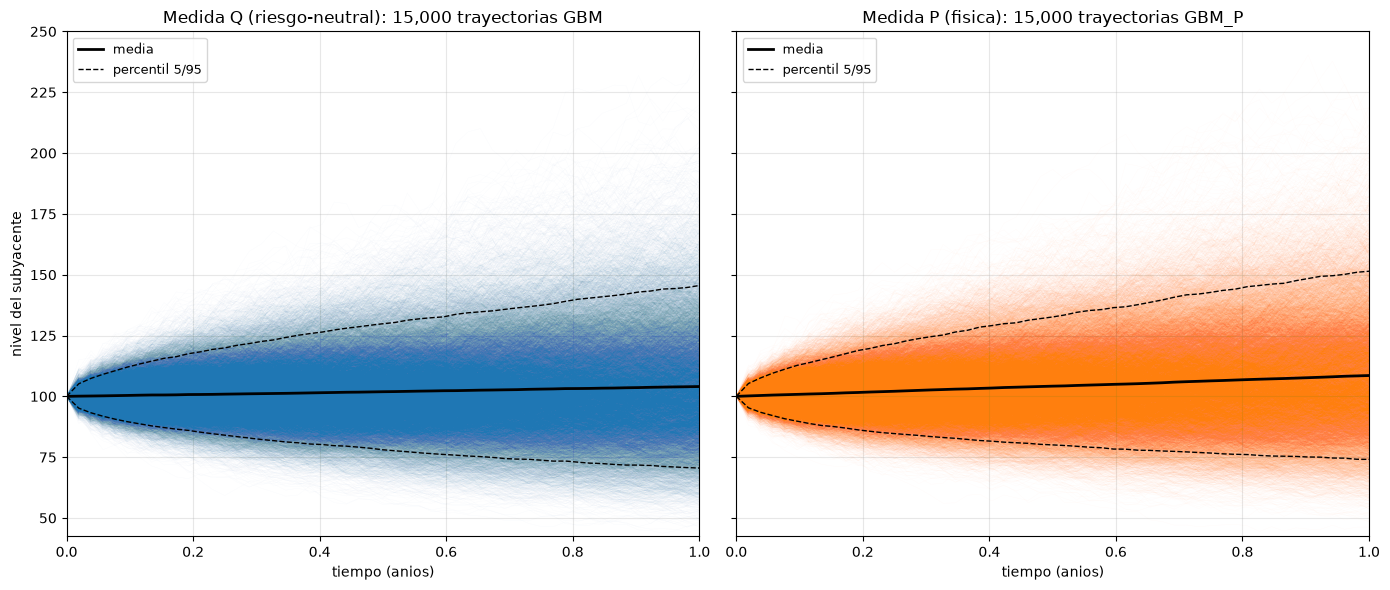

In [4]:
combined_min = min(paths_q.min(), paths_p.min())
combined_max = max(paths_q.max(), paths_p.max())
ylim = (combined_min * 0.97, combined_max * 1.03)


def fan_chart(ax, times, paths, color, title, ylim):
    segments = np.stack([np.tile(times, (paths.shape[0], 1)), paths], axis=2)
    ax.add_collection(LineCollection(segments, colors=color, alpha=0.02, linewidths=0.4))
    mean_path = paths.mean(axis=0)
    p05 = np.percentile(paths, 5, axis=0)
    p95 = np.percentile(paths, 95, axis=0)
    ax.plot(times, mean_path, color="black", linewidth=2, label="media")
    ax.plot(times, p05, color="black", linewidth=1, linestyle="--", label="percentil 5/95")
    ax.plot(times, p95, color="black", linewidth=1, linestyle="--")
    ax.set_xlim(times.min(), times.max())
    ax.set_ylim(*ylim)
    ax.set_xlabel("tiempo (anios)")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fan_chart(axes[0], times, paths_q, "tab:blue", f"Medida Q (riesgo-neutral): {N_PATHS:,} trayectorias GBM", ylim)
fan_chart(axes[1], times, paths_p, "tab:orange", f"Medida P (fisica): {N_PATHS:,} trayectorias GBM_P", ylim)
axes[0].set_ylabel("nivel del subyacente")
plt.tight_layout()
plt.show()


## 3. Estadisticas terminales: distribucion de $S_T$ bajo Q vs P


In [5]:
def terminal_stats(paths):
    s_t = paths[:, -1]
    mean = s_t.mean()
    std = s_t.std(ddof=1)
    skew = ((s_t - mean) ** 3).mean() / std ** 3
    kurt = ((s_t - mean) ** 4).mean() / std ** 4 - 3.0
    return {
        "media": mean, "mediana": float(np.median(s_t)), "desv. tipica": std,
        "asimetria": skew, "curtosis (exceso)": kurt,
        "p5": float(np.percentile(s_t, 5)), "p95": float(np.percentile(s_t, 95)),
        "min": s_t.min(), "max": s_t.max(),
    }


def analytic_gbm_moments(s0, drift, sigma, t):
    mean = s0 * math.exp(drift * t)
    var = s0 ** 2 * math.exp(2.0 * drift * t) * (math.exp(sigma * sigma * t) - 1.0)
    return mean, math.sqrt(var)


stats_q, stats_p = terminal_stats(paths_q), terminal_stats(paths_p)
mean_q_an, std_q_an = analytic_gbm_moments(S0, R - Q_DIV, SIGMA, T)
mean_p_an, std_p_an = analytic_gbm_moments(S0, MU, SIGMA, T)

print(f"{'':20}{'Q simulada':>13}{'Q analitica':>13}{'P simulada':>13}{'P analitica':>13}")
print(f"{'media':20}{stats_q['media']:13.3f}{mean_q_an:13.3f}{stats_p['media']:13.3f}{mean_p_an:13.3f}")
print(f"{'desv. tipica':20}{stats_q['desv. tipica']:13.3f}{std_q_an:13.3f}{stats_p['desv. tipica']:13.3f}{std_p_an:13.3f}")
print(f"{'':20}{'Q':>13}{'':13}{'P':>13}")
for key in ["mediana", "asimetria", "curtosis (exceso)", "p5", "p95", "min", "max"]:
    print(f"{key:20}{stats_q[key]:13.3f}{'':13}{stats_p[key]:13.3f}")


                       Q simulada  Q analitica   P simulada  P analitica
media                     104.039      104.081      108.562      108.329
desv. tipica               23.172       23.178       23.953       24.124
                                Q                         P
mediana                   101.691                   106.005
asimetria                   0.657                     0.660
curtosis (exceso)           0.788                     0.707
p5                         70.521                    74.078
p95                       145.562                   151.434
min                        45.173                    46.250
max                       242.768                   227.567


## 4. Distribucion terminal: histograma empirico vs lognormal teorica

Bajo un GBM, `S_T` es exactamente lognormal -- el histograma de las trayectorias simuladas
debe encajar con la densidad cerrada, tanto bajo Q como bajo P (misma `sigma`, distinta
media por la distinta deriva).


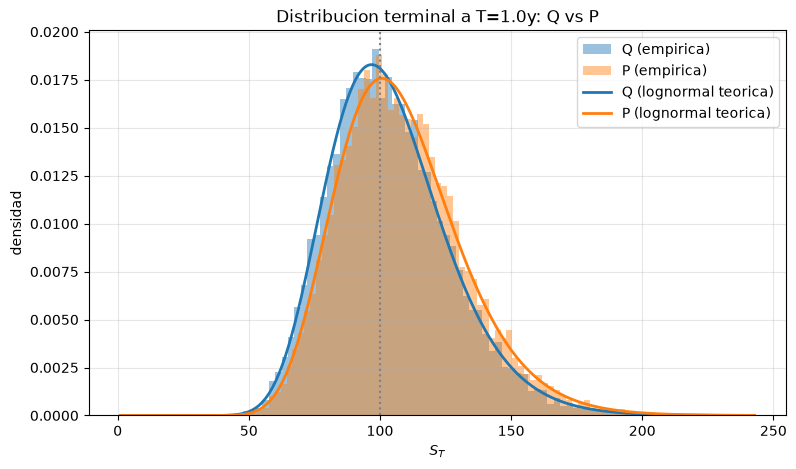

In [6]:
def lognormal_pdf(x, drift, sigma, t, s0):
    mu_log = math.log(s0) + (drift - 0.5 * sigma * sigma) * t
    sigma_log = sigma * math.sqrt(t)
    return np.exp(-0.5 * ((np.log(x) - mu_log) / sigma_log) ** 2) / (x * sigma_log * math.sqrt(2.0 * math.pi))


x_grid = np.linspace(1.0, max(paths_q[:, -1].max(), paths_p[:, -1].max()), 400)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(paths_q[:, -1], bins=80, density=True, alpha=0.45, color="tab:blue", label="Q (empirica)")
ax.hist(paths_p[:, -1], bins=80, density=True, alpha=0.45, color="tab:orange", label="P (empirica)")
ax.plot(x_grid, lognormal_pdf(x_grid, R - Q_DIV, SIGMA, T, S0), color="tab:blue", linewidth=2, label="Q (lognormal teorica)")
ax.plot(x_grid, lognormal_pdf(x_grid, MU, SIGMA, T, S0), color="tab:orange", linewidth=2, label="P (lognormal teorica)")
ax.axvline(S0, color="grey", linestyle=":")
ax.set_xlabel("$S_T$")
ax.set_ylabel("densidad")
ax.set_title(f"Distribucion terminal a T={T}y: Q vs P")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## 5. Validacion cruzada contra el motor real

### 5a. Esperanza: `Engine.simulate_paths` vs `PayoffPriceQ`/`PayoffForecastP` del motor

Dos caminos INTERNOS distintos del motor sobre la MISMA dinamica GBM/GBM_P: `stats_q`/`stats_p`
(seccion 3) vienen de agregar a mano las trayectorias crudas de `Engine.simulate_paths`;
`PayoffPriceQ`/`PayoffForecastP` son la medida agregada que calcula el motor internamente (con
su propia simulacion, no reutiliza `paths_q`/`paths_p`). `PayoffPriceQ` sobre un contrato que
paga el propio fixing a `T` da el valor PRESENTE descontado de `E_Q[S_T]` -- multiplicar por
`e^{rT}` (misma curva plana `R` usada en `market`) recupera `E_Q[S_T]`. `PayoffForecastP` ya da
`E_P[S_T]` directamente (notebook `05`).


In [7]:
pricing_hi = q.PricingContext(pricing_date=0.0, n_paths=300_000, n_steps=1, seed=7)

forward_contract = q.when(T, q.cashflow("USD", q.fixing(OBS, T)))
forward_trade = q.PayoffProduct(id="FWD", contract=forward_contract)

price_q_engine = eng.price(forward_trade, model_q, market, ["PayoffPriceQ"], pricing=pricing_hi).PayoffPriceQ.scalar
e_q_engine = price_q_engine * math.exp(R * T)
e_p_engine = eng.price(forward_trade, model_p, market, ["PayoffForecastP"], pricing=pricing_hi).PayoffForecastP.scalar

print(f"{'':22}{'simulate_paths':>16}{'PayoffPrice/ForecastP':>23}{'analitico':>13}")
print(f"{'E_Q[S_T]':22}{stats_q['media']:16.3f}{e_q_engine:23.3f}{mean_q_an:13.3f}")
print(f"{'E_P[S_T]':22}{stats_p['media']:16.3f}{e_p_engine:23.3f}{mean_p_an:13.3f}")


                        simulate_paths  PayoffPrice/ForecastP    analitico
E_Q[S_T]                       104.039                104.063      104.081
E_P[S_T]                       108.562                108.310      108.329


### 5b. Probabilidad de un evento: `Engine.simulate_paths` vs `PayoffHitProbabilityQ/P`

Fraccion de trayectorias que TOCAN una barrera bajista (-15% del spot) en cualquiera de las
`N_STEPS` fechas de monitoreo semanal -- calculada dos veces de forma independiente: a mano
sobre `paths_q`/`paths_p` (`Engine.simulate_paths`), y con el motor real via un `trigger` con
las MISMAS fechas de monitoreo (`PayoffHitProbabilityQ/P`, su propia simulacion interna).


In [8]:
barrier = S0 * 0.85
monitoring_times = [float(t) for t in times[1:]]

hit_empirical_q = float(np.mean(np.any(paths_q <= barrier, axis=1)))
hit_empirical_p = float(np.mean(np.any(paths_p <= barrier, axis=1)))

condition = q.less_equal(q.current(OBS), barrier)
crash_contract = q.trigger(
    "CRASH", monitoring_times, condition, "discrete", "at_hit", 0, True,
    q.when(T, q.cashflow("USD", 1.0)), q.zero(),
)
crash_trade = q.PayoffProduct(id="CRASH", contract=crash_contract)
pricing_hit = q.PricingContext(pricing_date=0.0, n_paths=100_000, n_steps=1, seed=7)

hit_engine_q = eng.price(crash_trade, model_q, market, [("PayoffHitProbabilityQ", {"event": "CRASH"})], pricing=pricing_hit)["PayoffHitProbabilityQ"].scalar
hit_engine_p = eng.price(crash_trade, model_p, market, [("PayoffHitProbabilityP", {"event": "CRASH"})], pricing=pricing_hit)["PayoffHitProbabilityP"].scalar

print(f"P(toca {barrier:.0f}, -15% del spot, antes de T={T}y)")
print(f"{'':10}{'simulate_paths':>16}{'PayoffHitProbability':>22}")
print(f"{'Q':10}{hit_empirical_q:16.1%}{hit_engine_q:22.1%}")
print(f"{'P':10}{hit_empirical_p:16.1%}{hit_engine_p:22.1%}")
print(f"\ncomo mu={MU:.0%} > r-q={R - Q_DIV:.0%}, bajo P el activo tiende a crecer mas rapido que bajo Q, "
      f"asi que la probabilidad fisica (P) de tocar una barrera bajista sale menor que la de mercado (Q).")


P(toca 85, -15% del spot, antes de T=1.0y)
            simulate_paths  PayoffHitProbability
Q                    38.8%                 39.1%
P                    33.2%                 33.3%

como mu=8% > r-q=4%, bajo P el activo tiende a crecer mas rapido que bajo Q, asi que la probabilidad fisica (P) de tocar una barrera bajista sale menor que la de mercado (Q).
